# Overfitting Model

by Niklas Vogel and Kevin Stupar

This notebook creates an overfitting model and evaluates it.
We used the `intel image classfification` data for thrainging out model.

It does the same, as the underfitting, just with a different model.

## Steps
- Loading, splitting and inspection fo the data
- Preparing the model and fitting it
- Evaluate the model

## Setup
Before executing this please make sure you did download and extract the [data](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc).
The Data must look like this: \<proj_name\>/.cache/extracted/seg_train/

Alternatively you can run setup.py

## Data Credit
- Initially published on https://datahack.analyticsvidhya.com
- Downloaded from https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- Photos by [Jan Böttinger on Unsplash](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc)

# Loading and splitting the data

The dataset contains six categories: buildings, forest, glacier, mountain, sea and street.
All classes have 2000 samples except street which has only 150.
This is guaranteed by our setup, which deletes excess images.

The dataset is loaded using the "image_dataset_from_directory" method from keras. This method also resizes the images to 64*64 pixels.
Next we shuffle the data using a seed so there is randomness in which go into training, validation and test split.
Using the seed we ensure the splits look the same for all models, but can be changed.

After shuffling we split the data into training, validation and test data.
- training: 56% (80% of non-test)
- validation: 14% (20% of non-test)
- test: 30%

After shuffling we split the data into 3 sections, where the first one is the training and the last one the test data.

In [ ]:
from helper import *
from tensorflow.keras import layers, models

image_size = (64, 64)
batch_size = 32

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.
Since we only have 150 streets, we will probably not see them here, but note that the images of streets often include buildings on the side.
This will be important later on.

In [ ]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 2000 images, except for street, which only has 150 images.

Also we can see that the data is split quite equally over all 3 splits.

In [ ]:
plot_numbers_per_classes({"All": all_images, "Train": train_images, "Validation": validation_images, "Test": test_images}, label_names)

# Building the model

Since we want an overfitting model (ca. 400'000 parameters) we use 5 layers.
More convolutional layers mean more feature extraction wich can lead to overfitting.
Also we add more filters per convolutional layer so even more features get extracted.
Between each layer we scale down the image using a max pooling to reduce the amount of parameters otherwise the fitting of the model would take ages.
By keeping MaxPooling saml we try to keep as much information until the end so the model can learns image specific features.
In the last layer we flatten the image from two dimensions into one and feed it onto a Dense layer.

As we can see in the summary below, the second layer has the most parameters, since the previous layer had 256 kernels, where as the first has only 3.

In [ ]:
model = models.Sequential([
    layers.Input(shape=image_size + (3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

# Compiling and Training the model

Here we compile the model and train it using the train and validation data.
We chose to use 30 Epochs here, so we can see clearly that the model is overfitting.

The training will take a while, why we recommend to use linux, since it is multiple times faster than windows.

In [ ]:
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.5159 - loss: 1.2030 - val_accuracy: 0.5620 - val_loss: 1.0848
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.6407 - loss: 0.9282 - val_accuracy: 0.6465 - val_loss: 0.9267
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.6891 - loss: 0.8346 - val_accuracy: 0.6782 - val_loss: 0.8714
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.7244 - loss: 0.7512 - val_accuracy: 0.7155 - val_loss: 0.7854
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7552 - loss: 0.6827 - val_accuracy: 0.7754 - val_loss: 0.6401
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7756 - loss: 0.6188 - val_accuracy: 0.8077 - val_loss: 0.5603
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7976 - loss: 0.5584 - val_accuracy: 0.8155 - val_loss: 0.5469
Epoch 8/30
177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8112 - loss: 0.5301

# Evaluating the model

## Preparing
To evaluate the model we first run some images through the model and look at the predictions the model has made.

After that we use those prediction together with the true values to plot some graphs and evaluate how good the models behaves and if it really overfits.

## Plots
### Accuracy/Loss
The first two plots show us the accuracy and the loss, where the loss is in a log y-scale, to better see the difference between the Epochs.

The training accuracy rises quick and then flattens out, where as the validation fluctuates quite ab it even from the beginning.
Despite this both seem to rise slowly to 99%.

### Confusion Matrix
We have 4 diffrent Confustion matrix plotted, which show us how often and waht the images has been classified as.
Firstly we can see that the last class (Karacadag) is not beeing clasified as good aas the others, due to the fact that it only has 150 images. Despite thsi it is quite good.
Secondly we can see that the classes 2 and 4 (Basmati and Jasmine) are mistaken for each other a few times, In the iamges plotted earlier we can see that both are slim and long, which explains it.

### Scores
The last three plots show us the F-score, Precision and Recall. All of them are very high except for the last class.

Accuracy: 0.7887323943661971
Loss: 1.1761693275199636


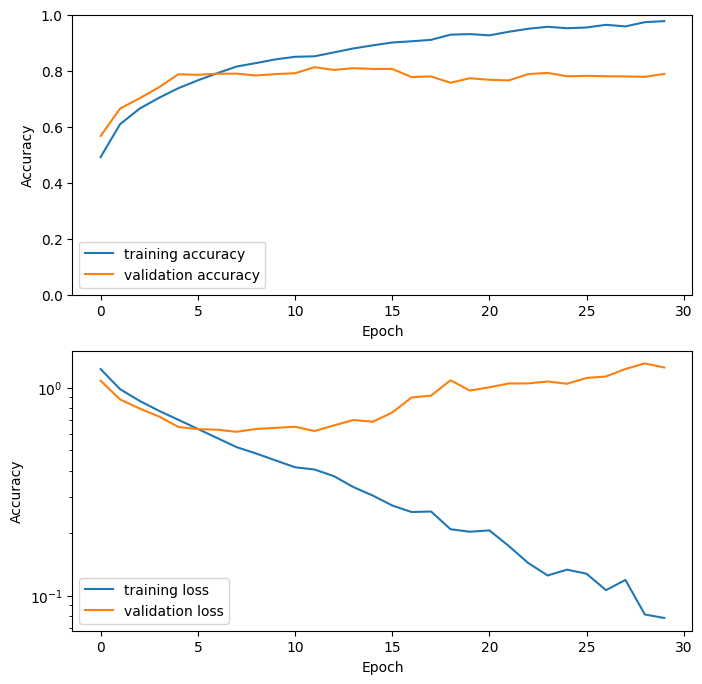

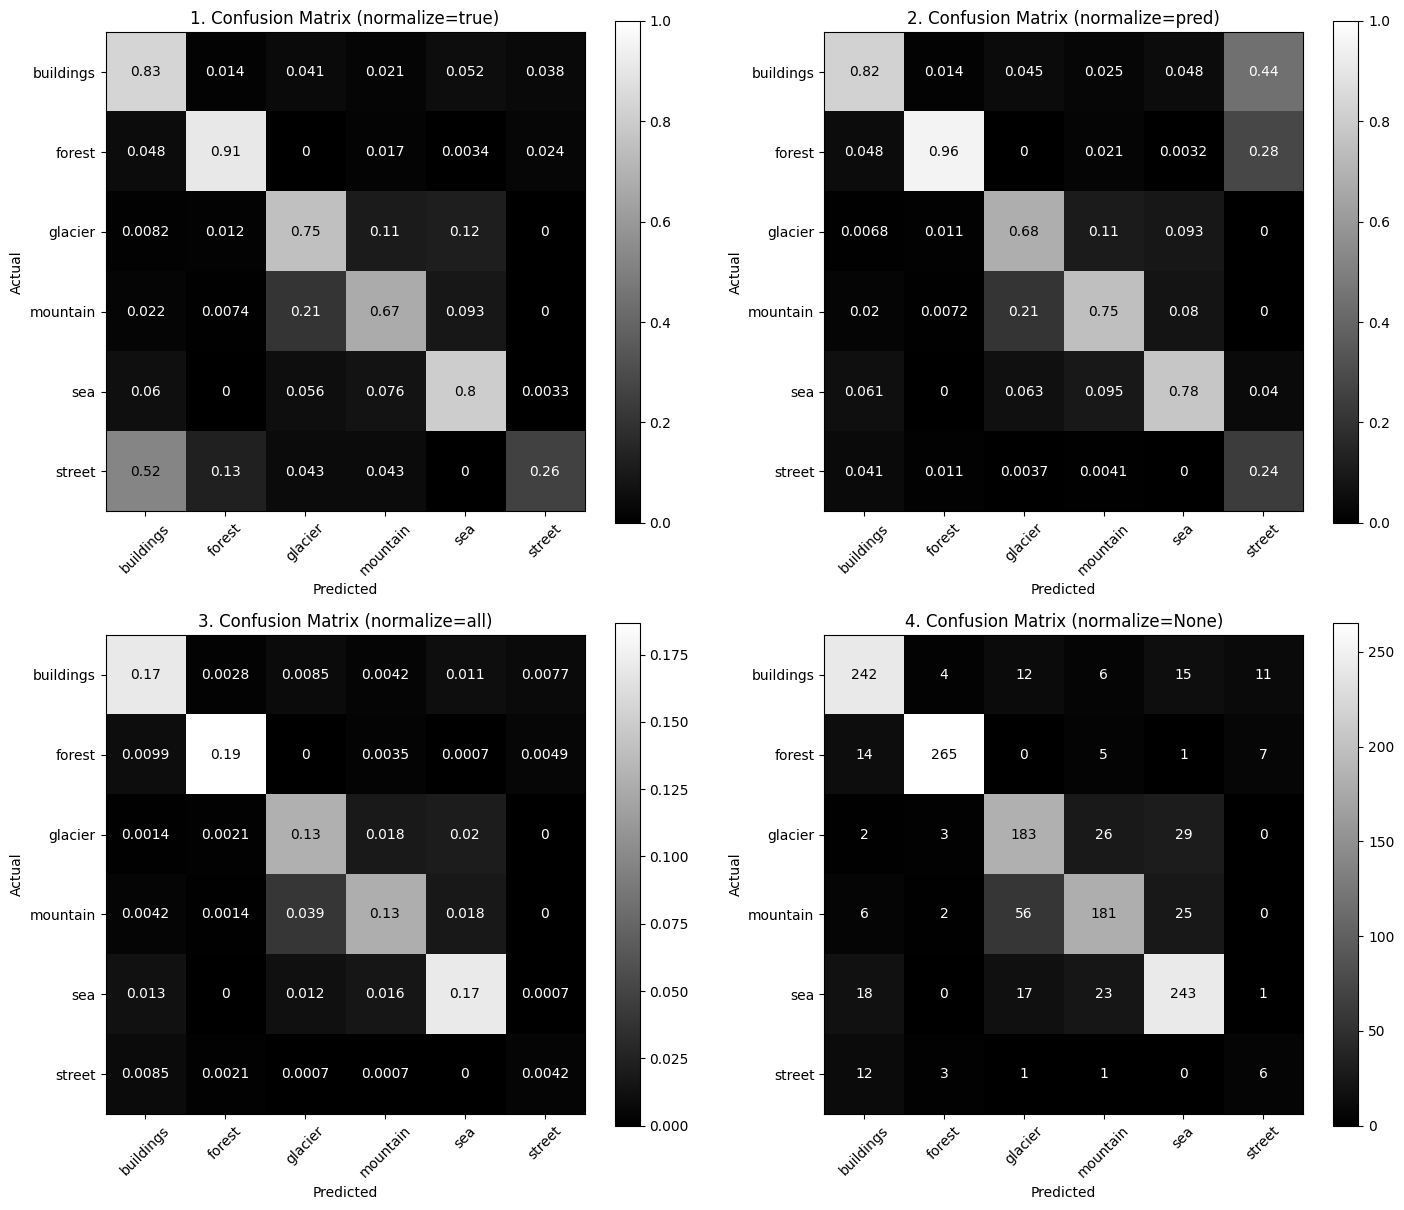

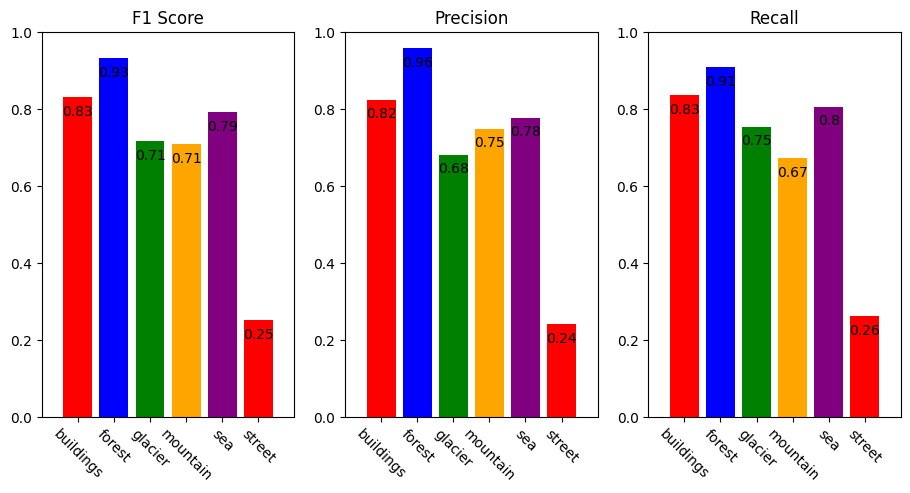

In [13]:
true, pred, pred_raw = calculate_predictions(model, validation_images.batch(batch_size))

print_accuracy_and_loss(model, validation_images.batch(batch_size))
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])
plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion
- Overall performance: The model has a training accuracy of about 1 and a validation accuracy of about 0.79. Training accuracy being significantly higher then validation accuracy means our model is overfitting.
- Accuracy: The training and validation accuracy go their own ways almost imidiatly. This means our model learns random noise from the images, which leads to high variance.
- Loss: The training loss gets close to 0 so on training data our model predicts perfectly. But interesting here is that the validation loss stays high so our model is very confident in its prediction even when its wrong.
- Confusion Metrix:
  1. Most interesting is that a streets always gets predicted either as building or forest so our model did not learn what a street is at all.
  2. Looking at street again we see that most street predictions are actually buildings. This might not jsut be because the model is bad but also many buildings have streets in their image making it extra hard. Also our model seams to struggle with differentiating between a glacier and mountain (also seen in 1.). This is probably due to the fact that glaciers apper in mountains.
  3. We see that no class realy dominates the models performance all classes except street get predicted quite well.
  4. This shows the massive unbalance in oure dataset with street having significantly less samples.
- Training metrics
    - F1 score: This tells us how balanced our model is, wich is not very balanced there are very little street samples. This is not surprising because we only have 150 street samples.
    - Precision: Here we see somthing intresting the scores of all classes is quite similar to our underfitting model except street which is much worse here probably because the model does not generalise.
    - Recall: The recall tells us that only a tiny amount of streets even get classified as such. So the model only predicts street if it is really confident, and even then its wrong most times as we can see by the precision.